In [54]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


def weighted_lehmar_mean(succeding_rates, individual_fitnesses, trial_fitnesses):
    improvements = individual_fitnesses - trial_fitnesses
    total_improvement = np.sum(improvements)
    weights = improvements / total_improvement

    lehmar_mean = np.sum(weights * succeding_rates**2) / np.sum(
        weights * succeding_rates
    )

    return lehmar_mean


def get_sample_from_cauchy(location: float, scale: float) -> float:
    quantile = np.random.rand()
    random_number = location + scale * np.tan(np.pi * quantile - np.pi / 2.0)
    return random_number


def setdiff1d(array1, elem):
    # Create a boolean mask for elements in array1 that are not in array2
    result_mask = np.ones(array1.shape[0], dtype=np.bool_)
    for i in range(array1.shape[0]):
        if array1[i] == elem:
            result_mask[i] = False

    return array1[result_mask]


def remove_rows(array, rows_to_remove):
    # Sort the indices to remove (optional but recommended for consistency)
    rows_to_remove = np.sort(rows_to_remove)

    mask = np.ones(array.shape[0], dtype=np.bool_)
    mask[rows_to_remove] = False

    return array[mask]


def get_clipped_number(number: float, lower_bound: float, upper_bound: float) -> float:
    if number < lower_bound:
        return lower_bound
    elif number > upper_bound:
        return upper_bound
    else:
        return number


def logical_or(arr1, arr2):
    result = np.empty(arr1.shape, dtype=np.bool_)
    for i in range(arr1.size):
        result[i] = bool(arr1[i]) | bool(arr2[i])
    return result


def are_individuals_close(
    individual_to_check: np.ndarray,
    reference_individual: np.ndarray,
    relative_tolerance: float,
    absolute_tolerance: float,
) -> bool:
    betas_to_check = individual_to_check[1:]
    betas_reference = reference_individual[1:]

    mus_rhos_to_check = individual_to_check[:1]
    mus_rhos_reference = reference_individual[:1]

    return np.all(
        logical_or(
            np.abs(mus_rhos_to_check - mus_rhos_reference)
            <= relative_tolerance * np.abs(mus_rhos_reference),
            np.abs(mus_rhos_to_check - mus_rhos_reference) <= absolute_tolerance,
        ),
    ) and np.all(
        np.abs(betas_to_check - betas_reference)
        <= relative_tolerance * np.abs(betas_reference)
    )


def get_reconstructed_individual(individual, fixed_parameters_values):
    result = fixed_parameters_values.copy()
    nan_indices = np.isnan(result)  # Find where NaNs are located
    result[nan_indices] = individual  # Replace NaNs with values from individual

    return result


def get_fitness_with_fixed_parameters(
    individual: np.ndarray,
    individual_index: int,
    fixed_parameters_values,
) -> float:
    return individual[0]


# I made some changes to this code, if it is correct implement em also in the lshade function
def lshade_save_info(
    gene_lower_boundaries,
    gene_upper_boundaries,
    initial_population,
    max_generations,
    memory_size,
    p,
    max_number_fitness_evaluations,
    number_of_best_individuals_without_neighborhood,
    relative_tolerance_for_best_individuals_neighborhood,
    absolute_tolerance_for_best_individuals_neighborhood,
    fixed_parameters_values: np.ndarray,  # array wih length n +n^2 + n^2 with nan if not fixed, fixed value if fixed
) -> np.ndarray:

    population_size = initial_population.shape[0]
    archive_size = initial_population.shape[0]
    problem_dimensionality = initial_population.shape[1]
    archive = np.zeros((archive_size, problem_dimensionality))
    archive_fitnesses = np.empty(archive_size)
    archive_fitnesses.fill(np.nan)

    memory = np.zeros((memory_size, 2)) + 0.5
    MEMORY_MCR_INDEX = 0
    MEMORY_MMR_INDEX = 1

    previous_gen_population = initial_population.copy()

    crossing_rates = np.zeros(population_size)
    mutation_rates = np.zeros(population_size)

    previous_gen_individuals_fitnesses = np.empty(population_size)
    for individual_index in range(population_size):
        previous_gen_individuals_fitnesses[individual_index] = (
            get_fitness_with_fixed_parameters(
                previous_gen_population[individual_index],
                individual_index,
                fixed_parameters_values,
            )
        )

    current_number_of_fitness_evaluations = population_size
    memory_index_to_update = 0

    min_number_of_individuals = 4
    generation_number = 1

    best_individual_fitness_index = np.argmin(previous_gen_individuals_fitnesses)
    global_best_individual = previous_gen_population[best_individual_fitness_index]
    global_best_individual_fitness = previous_gen_individuals_fitnesses[
        best_individual_fitness_index
    ]

    while (
        (generation_number <= max_generations)
        and (current_number_of_fitness_evaluations < max_number_fitness_evaluations)
        and (population_size > min_number_of_individuals)
    ):

        succeding_crossover_rates = np.empty(population_size)
        succeding_crossover_rates.fill(np.nan)
        succeding_mutation_rates = np.empty(population_size)
        succeding_mutation_rates.fill(np.nan)
        succeding_trials = np.empty((population_size, problem_dimensionality))
        succeding_trial_fitnesses = np.empty(population_size)
        succeding_trials_count = 0
        trail_individuals = np.empty((population_size, problem_dimensionality))
        trial_fitnesses = np.empty(population_size)
        are_individuals_surpassed = np.zeros(population_size)
        next_gen_individuals = previous_gen_population.copy()
        next_gen_individuals_fitnesses = previous_gen_individuals_fitnesses.copy()

        number_of_best_individuals = round(population_size * p)
        best_individuals_indices = np.argpartition(
            previous_gen_individuals_fitnesses, number_of_best_individuals
        )[:number_of_best_individuals]

        for individual_index in range(population_size):
            memory_index = np.random.randint(0, memory_size)
            if np.isnan(memory[memory_index, MEMORY_MCR_INDEX]):
                crossing_rates[individual_index] = 0
            else:
                crossing_rates[individual_index] = get_clipped_number(
                    np.random.normal(memory[memory_index, MEMORY_MCR_INDEX], 0.1),
                    0.0,
                    1.0,
                )

            generated_mutation_rate = 0
            while generated_mutation_rate <= 0:
                generated_mutation_rate = get_sample_from_cauchy(
                    memory[memory_index, MEMORY_MMR_INDEX], 0.1
                )
                if generated_mutation_rate > 1:
                    generated_mutation_rate = 1

            mutation_rates[individual_index] = generated_mutation_rate

            random_best_individual_index = np.random.randint(
                0, number_of_best_individuals
            )

            best_individual = previous_gen_population[
                best_individuals_indices[random_best_individual_index]
            ]

            number_individuals_in_archive = np.sum(~np.isnan(archive_fitnesses))
            individual_indices_not_current = setdiff1d(
                np.arange(population_size + number_individuals_in_archive),
                individual_index,
            )

            random_individual_indices = np.random.choice(
                individual_indices_not_current, 2, replace=False
            )

            random_individual_1 = (
                previous_gen_population[random_individual_indices[0]]
                if random_individual_indices[0] < population_size
                else archive[random_individual_indices[0] - population_size]
            )
            random_individual_2 = (
                previous_gen_population[random_individual_indices[1]]
                if random_individual_indices[1] < population_size
                else archive[random_individual_indices[1] - population_size]
            )
            current_individual = previous_gen_population[individual_index]

            mutant = (
                current_individual
                + mutation_rates[individual_index]
                * (best_individual - current_individual)
                + mutation_rates[individual_index]
                * (random_individual_1 - random_individual_2)
            )

            for gene_index in range(problem_dimensionality):
                if mutant[gene_index] < gene_lower_boundaries[gene_index]:
                    mutant[gene_index] = (
                        gene_lower_boundaries[gene_index]
                        + current_individual[gene_index]
                    ) / 2
                elif mutant[gene_index] > gene_upper_boundaries[gene_index]:
                    mutant[gene_index] = (
                        gene_upper_boundaries[gene_index]
                        + current_individual[gene_index]
                    ) / 2

            random_gene_index_to_mutate = np.random.randint(0, problem_dimensionality)
            crossover_gene_index = (
                np.random.rand(problem_dimensionality)
                < crossing_rates[individual_index]
            )
            crossover_gene_index[random_gene_index_to_mutate] = True

            trail_individual = np.where(
                crossover_gene_index, mutant, current_individual
            )
            trail_individuals[individual_index] = trail_individual
            trial_fitnesses[individual_index] = get_fitness_with_fixed_parameters(
                trail_individual,
                individual_index,
                fixed_parameters_values,
            )
            current_number_of_fitness_evaluations = (
                current_number_of_fitness_evaluations + 1
            )

        for individual_index in range(population_size):

            if (
                trial_fitnesses[individual_index]
                <= previous_gen_individuals_fitnesses[individual_index]
            ):
                next_gen_individuals[individual_index] = trail_individuals[
                    individual_index
                ]
                next_gen_individuals_fitnesses[individual_index] = trial_fitnesses[
                    individual_index
                ]

                if (
                    trial_fitnesses[individual_index]
                    < previous_gen_individuals_fitnesses[individual_index]
                ):
                    if number_individuals_in_archive < archive_size:
                        archive[number_individuals_in_archive] = trail_individuals[
                            individual_index
                        ]
                        archive_fitnesses[number_individuals_in_archive] = (
                            trial_fitnesses[individual_index]
                        )
                    else:
                        random_element_index = np.random.randint(0, archive_size)
                        archive[random_element_index] = trail_individuals[
                            individual_index
                        ]
                        archive_fitnesses[random_element_index] = trial_fitnesses[
                            individual_index
                        ]

                    succeding_mutation_rates[succeding_trials_count] = mutation_rates[
                        individual_index
                    ]
                    succeding_crossover_rates[succeding_trials_count] = crossing_rates[
                        individual_index
                    ]

                    succeding_trials[succeding_trials_count] = trail_individuals[
                        individual_index
                    ]
                    succeding_trial_fitnesses[succeding_trials_count] = trial_fitnesses[
                        individual_index
                    ]

                    are_individuals_surpassed[individual_index] = 1

                    succeding_trials_count += 1

                    if (
                        trial_fitnesses[individual_index]
                        < global_best_individual_fitness
                    ):
                        global_best_individual = trail_individuals[individual_index]
                        global_best_individual_fitness = trial_fitnesses[
                            individual_index
                        ]

        if succeding_trials_count > 0:
            if np.nanmax(succeding_mutation_rates) <= 0 or np.isnan(
                memory[memory_index_to_update, MEMORY_MCR_INDEX]
            ):
                memory[memory_index_to_update, MEMORY_MCR_INDEX] = np.nan
            else:
                memory[memory_index_to_update, MEMORY_MCR_INDEX] = weighted_lehmar_mean(
                    succeding_crossover_rates[:succeding_trials_count],
                    previous_gen_individuals_fitnesses[are_individuals_surpassed == 1],
                    succeding_trial_fitnesses[:succeding_trials_count],
                )

            memory[memory_index_to_update, MEMORY_MMR_INDEX] = weighted_lehmar_mean(
                succeding_mutation_rates[:succeding_trials_count],
                previous_gen_individuals_fitnesses[are_individuals_surpassed == 1],
                succeding_trial_fitnesses[:succeding_trials_count],
            )

            memory_index_to_update = (memory_index_to_update + 1) % memory_size

        # Here goes the code to remove neighbors of the best individuals
        if population_size >= number_of_best_individuals_without_neighborhood:
            best_individuals_indices_to_remove_neighborhood = np.argpartition(
                next_gen_individuals_fitnesses,
                number_of_best_individuals_without_neighborhood,
            )[:number_of_best_individuals_without_neighborhood]

            best_individuals_indices_to_remove_neighborhood = (
                best_individuals_indices_to_remove_neighborhood[
                    np.argsort(
                        next_gen_individuals_fitnesses[
                            best_individuals_indices_to_remove_neighborhood
                        ]
                    )
                ]
            )

            individual_indices_close_to_best_individuals = np.zeros(
                population_size, dtype=int
            )
            for i, current_best_individual_index in enumerate(
                best_individuals_indices_to_remove_neighborhood
            ):
                for individual_index in range(population_size):
                    if (
                        individual_index != current_best_individual_index
                        and individual_index
                        not in best_individuals_indices_to_remove_neighborhood[:i]
                    ):
                        if are_individuals_close(
                            next_gen_individuals[individual_index],
                            next_gen_individuals[current_best_individual_index],
                            relative_tolerance_for_best_individuals_neighborhood,
                            absolute_tolerance_for_best_individuals_neighborhood,
                        ):
                            individual_indices_close_to_best_individuals[
                                individual_index
                            ] = 1
        else:
            individual_indices_close_to_best_individuals = np.zeros(
                population_size, dtype=int
            )

        individual_indices_to_remove = np.where(
            individual_indices_close_to_best_individuals == 1
        )[0]

        next_gen_population_size = round(
            (
                (min_number_of_individuals - initial_population.shape[0])
                / max_number_fitness_evaluations
            )
            * current_number_of_fitness_evaluations
            + initial_population.shape[0]
        )

        if next_gen_population_size < population_size:
            if next_gen_population_size < min_number_of_individuals:
                next_gen_individuals = np.empty((0, 2))
                next_gen_individuals_fitnesses = np.empty(0)
            else:
                number_of_individuals_to_delete = (
                    population_size - next_gen_population_size
                )
                worst_individuals_indices = np.argpartition(
                    next_gen_individuals_fitnesses, -number_of_individuals_to_delete
                )[-number_of_individuals_to_delete:]

                if len(individual_indices_to_remove) > 0:
                    ending_index_to_remove = (
                        (len(individual_indices_to_remove) - min_number_of_individuals)
                        if (
                            next_gen_population_size - len(individual_indices_to_remove)
                            < min_number_of_individuals
                        )
                        else len(individual_indices_to_remove)
                    )

                    worst_individuals_indices = np.unique(
                        np.concatenate(
                            (
                                individual_indices_to_remove[:ending_index_to_remove],
                                worst_individuals_indices,
                            )
                        )
                    )

                next_gen_individuals = remove_rows(
                    next_gen_individuals, worst_individuals_indices
                )
                next_gen_individuals_fitnesses = np.delete(
                    next_gen_individuals_fitnesses, worst_individuals_indices
                )
                population_size = population_size - len(worst_individuals_indices)

        previous_gen_population = next_gen_individuals
        previous_gen_individuals_fitnesses = next_gen_individuals_fitnesses
        generation_number = generation_number + 1

    return global_best_individual

In [55]:
gene_lower_boundaries = np.array([0] * 2)
gene_upper_boundaries = np.array([1] * 2)
np.random.seed(0)
initial_population = np.random.rand(1000, 2)
max_generations = 20
memory_size = 10
p = 0.33
max_number_fitness_evaluations = 3000
number_of_best_individuals_without_neighborhood = 20
relative_tolerance_for_best_individuals_neighborhood = 0.03
absolute_tolerance_for_best_individuals_neighborhood = 0.08
fixed_parameters_values = np.array([np.nan] * 2)

best_ind = lshade_save_info(
    gene_lower_boundaries,
    gene_upper_boundaries,
    initial_population,
    max_generations,
    memory_size,
    p,
    max_number_fitness_evaluations,
    number_of_best_individuals_without_neighborhood,
    relative_tolerance_for_best_individuals_neighborhood,
    absolute_tolerance_for_best_individuals_neighborhood,
    fixed_parameters_values,
)

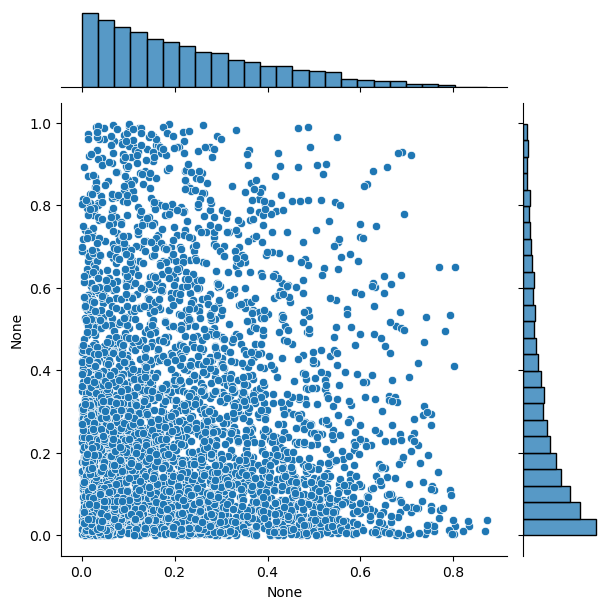

Eliminated 9996181 points with spectral radius > 1


In [ ]:
import numpy as np
from scipy.stats.qmc import Halton
import seaborn as sns


def generate_halton_sequence(n_points, n_dim, bounds):
    """
    Generate a Halton sequence in R^n with given constraints per dimension.

    Parameters:
    - n_points: int, number of points to generate
    - n_dim: int, number of dimensions
    - bounds: list of tuples, each tuple (min, max) for each dimension

    Returns:
    - np.ndarray of shape (n_points, n_dim) with generated points
    """

    if len(bounds) != n_dim:
        raise ValueError("Number of bounds must match the number of dimensions")

    sampler = Halton(d=n_dim, scramble=True)
    halton_points = sampler.random(n=n_points)

    # Scale to given bounds
    scaled_points = np.zeros_like(halton_points)
    for i in range(n_dim):
        min_val, max_val = bounds[i]
        scaled_points[:, i] = min_val + (max_val - min_val) * halton_points[:, i]

    return scaled_points


n_dim = 36
mat_size = np.sqrt(n_dim).astype(int)
# Example: Define constraints for 36 dimensions
bounds = [(0, 1) for _ in range(n_dim)]

# Generate Halton sequence with 300000 points in 36D
n_points = 100_000_000
halton_data = generate_halton_sequence(n_points, n_dim, bounds)
plt.plot(halton_data[:, 0], halton_data[:, 1], ".")
plt.show()


def get_spectral_radius(matrix: np.ndarray) -> float:
    eigenvalues = np.linalg.eigvals(matrix.astype(np.complex128))
    return np.max(np.abs(eigenvalues))


# remove values with spectral radius > 1
removed = 0
for i in range(halton_data.shape[0]):
    matrix = halton_data[i].reshape((mat_size, mat_size))

    if get_spectral_radius(matrix) > 1:
        halton_data[i] = np.nan
        removed += 1

# save a copy without NaNs
halton_data_no_nan = halton_data[~np.isnan(halton_data).any(axis=1)]
np.save("halton_data_no_nan.npy", halton_data_no_nan)

sns.jointplot(
    x=halton_data_no_nan[:, 0],
    y=halton_data_no_nan[:, 1],
    marginal_kws=dict(bins=25, fill=True),
)
plt.show()

print(f"Eliminated {removed} points with spectral radius > 1")

In [68]:
n_points - removed

3819

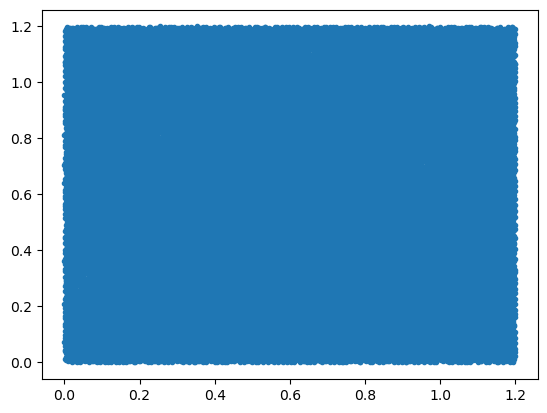

finished


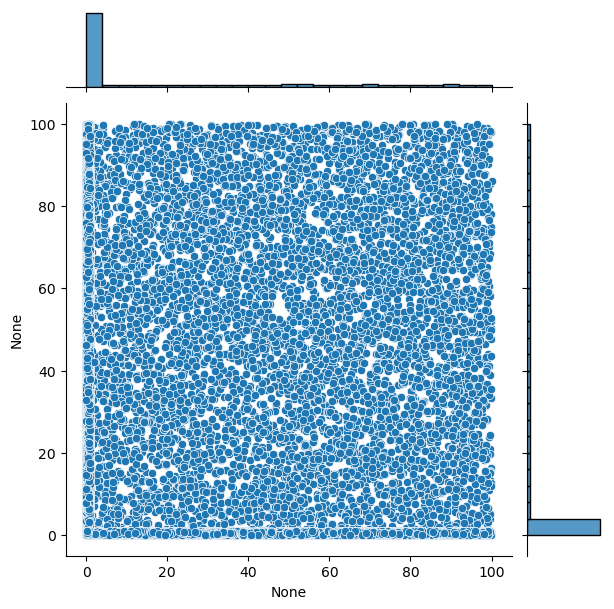

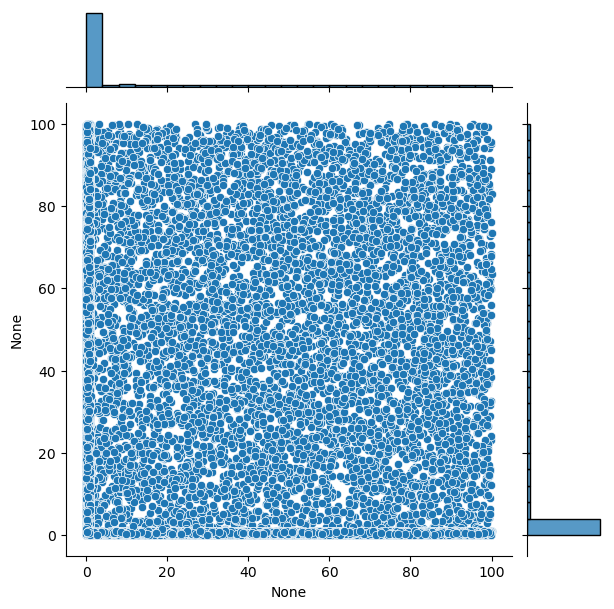

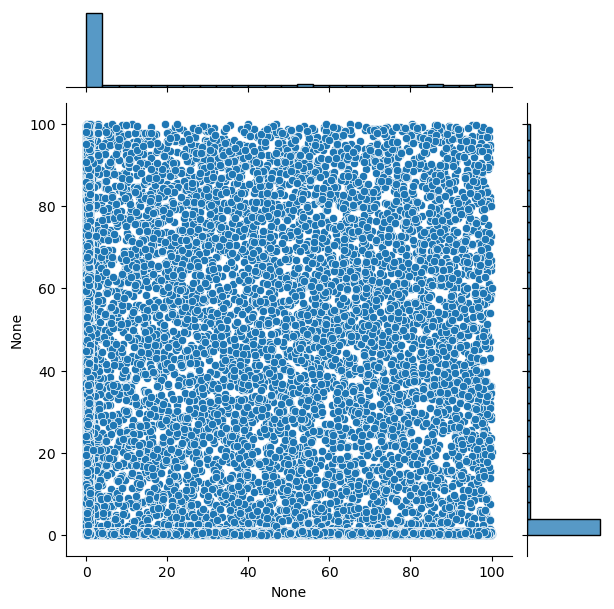

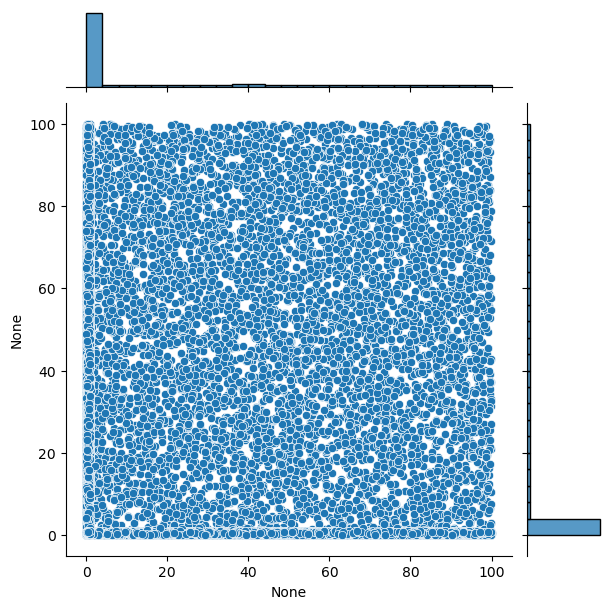

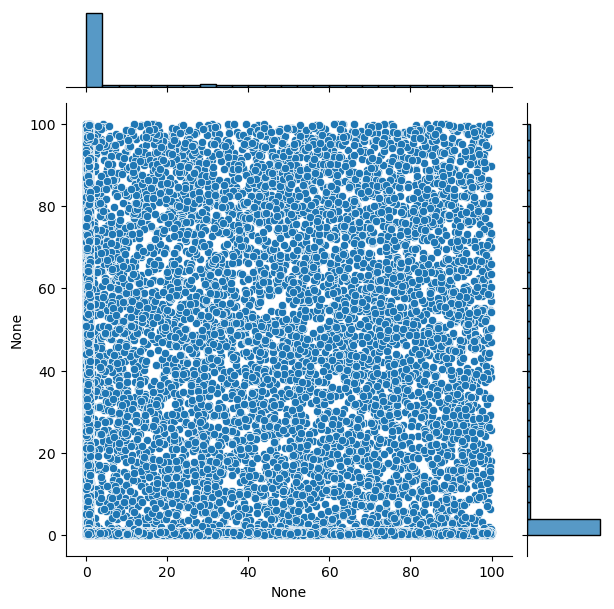

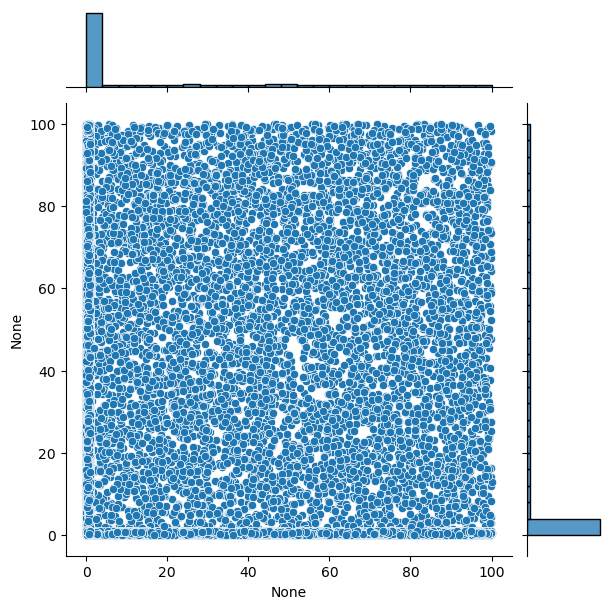

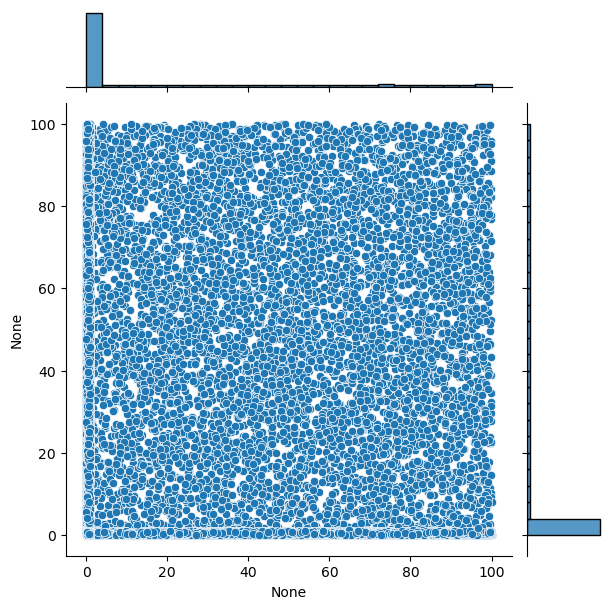

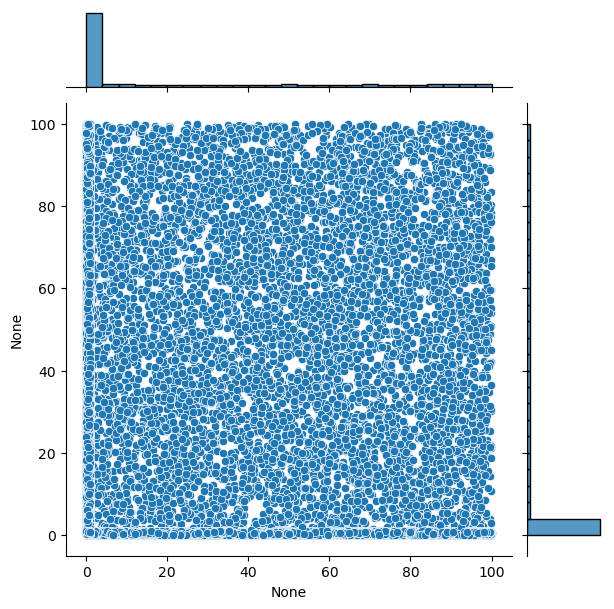

Eliminated 0 points with spectral radius > 1


In [27]:
import numpy as np
from scipy.stats.qmc import Halton
import seaborn as sns
import matplotlib.pyplot as plt


def generate_halton_sequence(n_points, n_dim, bounds):
    """
    Generate a Halton sequence in R^n with given constraints per dimension.

    Parameters:
    - n_points: int, number of points to generate
    - n_dim: int, number of dimensions
    - bounds: list of tuples, each tuple (min, max) for each dimension

    Returns:
    - np.ndarray of shape (n_points, n_dim) with generated points
    """

    if len(bounds) != n_dim:
        raise ValueError("Number of bounds must match the number of dimensions")

    sampler = Halton(d=n_dim, scramble=True)
    halton_points = sampler.random(n=n_points)

    # Scale to given bounds
    scaled_points = np.zeros_like(halton_points)
    for i in range(n_dim):
        min_val, max_val = bounds[i]
        scaled_points[:, i] = min_val + (max_val - min_val) * halton_points[:, i]

    return scaled_points


n_dim = 16
mat_size = np.sqrt(n_dim).astype(int)
n_total_dim = n_dim * 2 + mat_size

# Example: Define constraints for 36 dimensions
bounds = (
    [(0, 1.2) for _ in range(mat_size)]
    + [(0, 1) for _ in range(n_dim)]
    + [(0, 1) for _ in range(n_dim)]
)

# Generate Halton sequence with 300000 points in 36D
n_points = 30_000
halton_data = generate_halton_sequence(n_points, n_total_dim, bounds)
plt.plot(halton_data[:, 0], halton_data[:, 1], ".")
plt.show()


def get_spectral_radius(matrix: np.ndarray) -> float:
    eigenvalues = np.linalg.eigvals(matrix.astype(np.complex128))
    return np.max(np.abs(eigenvalues))


def update_matrix(matrix, lower_spectral_radius=0.3):
    """Update the matrix by setting an element to np.random.exponential(0.1)
    while following the probability rule."""
    rows, cols = matrix.shape
    chosen_indices = set()  # Keep track of already modified indices

    spectral_radius = get_spectral_radius(matrix)
    if spectral_radius < lower_spectral_radius:
        num_elements = np.random.randint(1, rows)
        partial_increment = 1 / num_elements
        for _ in range(num_elements):
            i, j = np.random.randint(0, rows, size=2)
            matrix[i, j] += partial_increment

    while get_spectral_radius(matrix) >= 1:
        # Compute probabilities for selection (higher for elements near zero)
        prob_matrix = 1 / (
            np.abs(matrix) + 1e-10
        )  # Small epsilon to prevent div by zero
        for x, y in chosen_indices:
            prob_matrix[x, y] = 0.01
        prob_matrix /= np.sum(prob_matrix)  # Normalize to get probabilities

        # Choose a random index based on probability distribution
        flat_index = np.random.choice(rows * cols, p=prob_matrix.ravel())
        i, j = divmod(flat_index, cols)

        # Update the selected element with an exponential(0.1) random value
        matrix[i, j] = np.random.exponential(0.1)

        # Mark this index as chosen
        chosen_indices.add((i, j))

    matrix = np.clip(matrix, 0, 0.95)

    return matrix


def modify_random_elements(matrix):
    # Get the shape of the matrix
    n, m = matrix.shape

    # Calculate total elements and how many to change (50%)
    total_elements = n * m
    num_elements_to_modify = total_elements // 2

    # Create a random mask with the indices to modify
    indices = np.random.choice(total_elements, num_elements_to_modify, replace=False)

    # Flatten the matrix and apply the mask
    flattened_matrix = matrix.flatten()
    flattened_matrix[indices] = np.random.uniform(0, 100, size=num_elements_to_modify)

    # Reshape the matrix back to its original shape
    matrix = flattened_matrix.reshape(n, m)

    return matrix


# remove values with spectral radius > 1
removed = 0
for i in range(halton_data.shape[0]):
    individual_rhos = halton_data[i, mat_size : mat_size + n_dim]
    matrix = individual_rhos.reshape((mat_size, mat_size))
    matrix = update_matrix(matrix)
    halton_data[i, mat_size : mat_size + n_dim] = matrix.flatten()

    individual_betas = halton_data[i, mat_size + n_dim : n_total_dim]
    matrix = individual_betas.reshape((mat_size, mat_size))
    matrix = modify_random_elements(matrix)
    halton_data[i, mat_size + n_dim : n_total_dim] = matrix.flatten()


print("finished")

for x in range(20, n_total_dim, 2):
    sns.jointplot(
        x=halton_data[:, x],
        y=halton_data[:, x + 1],
        marginal_kws=dict(bins=25, fill=True),
    )
    plt.show()

print(f"Eliminated {removed} points with spectral radius > 1")

The solution is generate a lot of samples with halton and remove them. Now lshade work for how it is implemented in this notebook, so we can try to do an attempt with halton generated population. we will scale the beta values after this selection, maybe coumputing at pairs the most similars and one beta is in (0,1) and the other is in (0,100)